<a href="https://colab.research.google.com/github/SowjanyaBV/Driver-Drowsiness-detector-analysis/blob/main/equipment_failure_warning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Equipment Failure Warning Using Logistic Regression**

In [1]:
from google.colab import files

uploaded = files.upload()

Saving dataset_06_equipment_failure_warning.csv to dataset_06_equipment_failure_warning.csv


In [2]:
import pandas as pd

df = pd.read_csv('dataset_06_equipment_failure_warning.csv')

In [3]:
df.head()

,temperature,vibration,pressure,runtime_hours,maintenance_gap_days,power_draw,target
0,62.10,1.01,86.17,1.00,16,63.81,0
1,78.78,0.10,95.62,17.13,54,298.61,1
2,76.70,5.28,130.00,19.59,29,245.18,1
3,88.05,4.22,93.83,1.04,52,328.36,1
4,71.58,6.59,103.01,19.12,43,345.48,0


**Step 1 — Dataset Inspection**

In [4]:
# Check the size of the dataset
print("Shape of dataset:", df.shape)

# Check column names
print("\nColumn names:")
print(df.columns.tolist())

# Display first 5 rows
print("\nFirst 5 rows:")
display(df.head())

# Check data types
print("\nData types:")
print(df.dtypes)

# Get overall dataset information
print("\nDataset information:")
df.info()

Shape of dataset: (1000, 7)

Column names:
['temperature', 'vibration', 'pressure', 'runtime_hours', 'maintenance_gap_days', 'power_draw', 'target']

First 5 rows:


,temperature,vibration,pressure,runtime_hours,maintenance_gap_days,power_draw,target
0,62.10,1.01,86.17,1.00,16,63.81,0
1,78.78,0.10,95.62,17.13,54,298.61,1
2,76.70,5.28,130.00,19.59,29,245.18,1
3,88.05,4.22,93.83,1.04,52,328.36,1
4,71.58,6.59,103.01,19.12,43,345.48,0



Data types:
temperature             float64
vibration               float64
pressure                float64
runtime_hours           float64
maintenance_gap_days      int64
power_draw              float64
target                    int64
dtype: object

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   temperature           1000 non-null   float64
 1   vibration             1000 non-null   float64
 2   pressure              1000 non-null   float64
 3   runtime_hours         1000 non-null   float64
 4   maintenance_gap_days  1000 non-null   int64  
 5   power_draw            1000 non-null   float64
 6   target                1000 non-null   int64  
dtypes: float64(5), int64(2)
memory usage: 54.8 KB


**Step 2 — Data Quality Checks**

In [5]:
# Check for missing values
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
temperature             0
vibration               0
pressure                0
runtime_hours           0
maintenance_gap_days    0
power_draw              0
target                  0
dtype: int64


In [ ]:
# Check for duplicate rows
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [6]:
# Check target class distribution
print("Target class counts:")
print(df['target'].value_counts())

print("\nTarget class percentages:")
print(df['target'].value_counts(normalize=True) * 100)

Target class counts:
target
0    500
1    500
Name: count, dtype: int64

Target class percentages:
target
0    50.0
1    50.0
Name: proportion, dtype: float64


In [7]:
# Check unique target values
print("Unique target values:")
print(df['target'].unique())

Unique target values:
[0 1]


In [8]:
# Check basic statistics for numerical variables
df.describe()

,temperature,vibration,pressure,runtime_hours,maintenance_gap_days,power_draw,target
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000
mean,70.175340,3.982960,100.048280,10.832150,30.271000,186.449680,0.50000
std,12.139762,1.675728,17.907478,7.146326,18.104788,150.152338,0.50025
min,30.320000,0.100000,40.190000,1.000000,0.000000,20.730000,0.00000
25%,61.605000,2.870000,87.585000,4.957500,15.000000,93.352500,0.00000
50%,70.475000,3.935000,100.475000,10.520000,30.000000,144.840000,0.50000
75%,78.167500,5.130000,112.477500,15.935000,47.000000,240.855000,1.00000
max,109.320000,8.370000,158.570000,34.860000,60.000000,1940.660000,1.00000


**Step 3 — Data Preprocessing**

In [9]:
# Separate input variables (X) and target variable (y)

X = df.drop('target', axis=1)
y = df['target']

print("Input variables:")
print(X.columns.tolist())

print("\nTarget variable:")
print(y.name)

Input variables:
['temperature', 'vibration', 'pressure', 'runtime_hours', 'maintenance_gap_days', 'power_draw']

Target variable:
target


**Step 4 — Train/Test Split**

In [10]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Check the sizes
print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True) * 100)

Training data shape: (800, 6)
Testing data shape: (200, 6)

Training target distribution:
target
1    50.0
0    50.0
Name: proportion, dtype: float64

Testing target distribution:
target
1    50.0
0    50.0
Name: proportion, dtype: float64


**Step 5 — Logistic Regression Model**

In [11]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

# Create a pipeline
model = Pipeline([
    ('scaler', StandardScaler()),
    ('logistic_regression', LogisticRegression(random_state=42))
])

# Train the model
model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [12]:
print(model)

Pipeline(steps=[('scaler', StandardScaler()),
                ('logistic_regression', LogisticRegression(random_state=42))])


**Step 6 — Model Evaluation**

In [13]:
# Make predictions on the test data
y_pred = model.predict(X_test)

# Get probability predictions for ROC-AUC
y_prob = model.predict_proba(X_test)[:, 1]

print("Predictions generated successfully.")

Predictions generated successfully.


In [14]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("Model Evaluation Results")
print("------------------------")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

Model Evaluation Results
------------------------
Accuracy : 0.7150
Precision: 0.7416
Recall   : 0.6600
F1-score : 0.6984
ROC-AUC  : 0.7788


In [15]:
from sklearn.metrics import confusion_matrix

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[77 23]
 [34 66]]


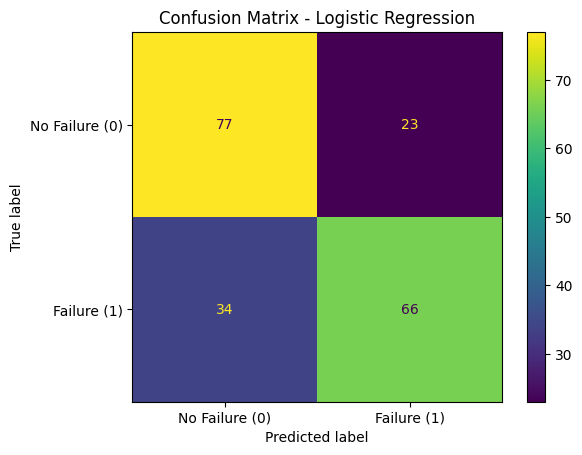

In [16]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["No Failure (0)", "Failure (1)"]
)

plt.title("Confusion Matrix - Logistic Regression")
plt.show()

**Step 7 — Feature Interpretation**

In [17]:
# Extract Logistic Regression coefficients
coefficients = model.named_steps['logistic_regression'].coef_[0]

# Create a table of features and coefficients
feature_effects = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': coefficients
})

# Sort by coefficient
feature_effects = feature_effects.sort_values(
    by='Coefficient',
    ascending=False
)

print("Feature Coefficients:")
display(feature_effects)

Feature Coefficients:


,Feature,Coefficient
2,pressure,0.549647
0,temperature,0.546244
4,maintenance_gap_days,0.441876
1,vibration,-0.365118
3,runtime_hours,-0.414691
5,power_draw,-0.458667


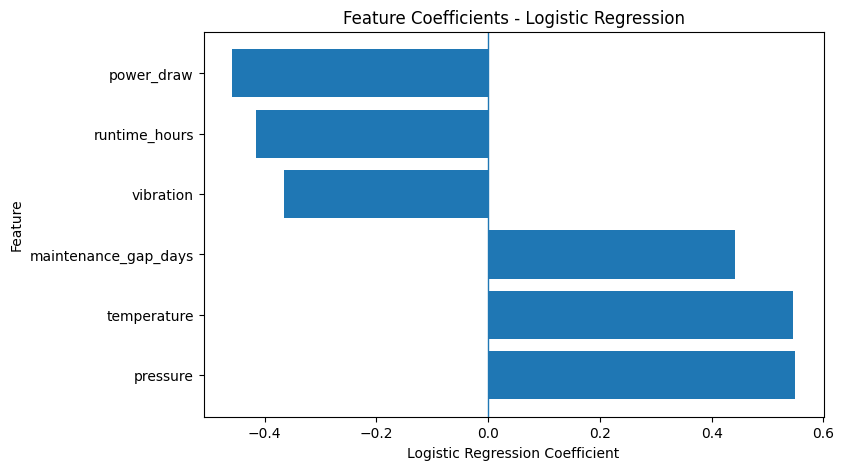

In [18]:
# Plot feature coefficients
plt.figure(figsize=(8, 5))

plt.barh(
    feature_effects['Feature'],
    feature_effects['Coefficient']
)

plt.axvline(0, linewidth=1)
plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")
plt.title("Feature Coefficients - Logistic Regression")

plt.show()

**Step 8 — Limitations & Conclusion**

## Limitations

1. The dataset is synthetic and is intended for educational practice, so the results may not represent real-world industrial equipment.

2. The model uses only six predictor variables. Other factors that may influence equipment failure are not included.

3. The Logistic Regression model assumes a relatively simple relationship between the predictors and the log-odds of failure. Complex relationships may not be captured.

4. The model was evaluated using a single train-test split. Therefore, performance may vary with a different sample split.

5. The model's predictions depend on the quality and range of the available data. Its performance may decrease when applied to equipment or operating conditions different from those represented in the dataset.

## Possible Improvements

1. Collect and use real-world equipment data from a wider range of machines and operating conditions.

2. Include additional variables that may help predict equipment failure.

3. Use cross-validation to obtain a more robust estimate of model performance.

4. Compare Logistic Regression with other classification algorithms to determine whether a more complex model provides better predictions.

5. Tune the model and decision threshold based on the practical cost of false positives and false negatives.

6. Continuously monitor model performance and retrain the model when new equipment data becomes available.

## Conclusion

A Logistic Regression model was developed to predict whether industrial equipment would experience failure within the next operating window. The dataset was inspected, checked for data-quality issues, and the predictor variables were standardized using a preprocessing pipeline. An 80/20 stratified train-test split was used to evaluate the model while reducing the risk of data leakage.

The model achieved an Accuracy of [YOUR VALUE], Precision of [YOUR VALUE], Recall of [YOUR VALUE], F1-score of [YOUR VALUE], and ROC-AUC of [YOUR VALUE].

The confusion matrix provides further insight into the model's correct and incorrect predictions. In particular, false negatives are important because they represent equipment failures that were not identified by the model.

Overall, the Logistic Regression model provides a useful baseline for equipment failure prediction on this dataset. However, because the dataset is synthetic and contains a limited number of predictors, further validation using real-world data and comparison with other models would be necessary before practical deployment.